In [1]:
# 

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm 
import matplotlib.ticker as ticker
from warnings import filterwarnings
filterwarnings('ignore')


In [2]:
# Professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color  = viridis_colors[2]
accent_color = viridis_colors[2]
danger_color = '#8000000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:

df = pd.read_csv("G:\Final Projects\Data Analysis Project\Supply Chain Analysis\Datasets\DataCoSupplyChainDataset.csv", encoding='latin-1')

In [4]:
df.head(4)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class


In [5]:
# overview of our data
df.shape

(180519, 53)

Exploratory Data Analysis(EDA)

In [6]:
#overview
print('rows, cols:',df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print("\nNo. of Duplicate Value:", df.duplicated().sum())
print('\nNo. of missing value:')
print(df.isna().sum().sort_values(ascending = False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

Data Cleaning

In [7]:
# Checking two columns has are the same values or not
(df['Benefit per order'] == df['Order Profit Per Order']).value_counts()
# Checking the 'product status' column has only one value
df['Product Status'].value_counts()


Product Status
0    180519
Name: count, dtype: int64

In [8]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order', #Identical to oerder profit per order
    'Product Status',
    'Customer City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market',

]

# Dropping the unnecessary column for Cleansiness
df = df.drop(columns = columns_to_drop)



In [9]:
df.shape

(180519, 21)

In [10]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'Order City', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [11]:
# Delete all the canceled orders
df = df[df['Delivery Status'] != 'Shipping canceled']

In [12]:
df.head(4)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,1/31/2018 22:56,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,1/13/2018 12:27,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,1/13/2018 12:06,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,1/13/2018 11:45,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,1/16/2018 11:45,Standard Class


In [13]:
# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst = False) 
df['order date (DateOrders)']
df['shipping date (DateOrders)']

0        2018-02-03 22:56:00
1        2018-01-18 12:27:00
2        2018-01-17 12:06:00
3        2018-01-16 11:45:00
4        2018-01-15 11:24:00
                 ...        
180514   2016-01-20 03:40:00
180515   2016-01-19 01:34:00
180516   2016-01-20 21:00:00
180517   2016-01-18 20:18:00
180518   2016-01-19 18:54:00
Name: shipping date (DateOrders), Length: 172765, dtype: datetime64[ns]

In [14]:
df.columns
df.shape


(172765, 21)

In [15]:
# After the data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending= False).head(5))

rows, cols (172765, 21)

Missing values (top 5):
Type                          0
order date (DateOrders)       0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [16]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [17]:
# Calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)']- df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay']>0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_day,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,15.739803,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,8.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,16.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,23.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,31.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,8.823467,6.927276


In [18]:
df['Is_Delayed'].value_counts()


Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [19]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'Order City', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time',
       'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [20]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [21]:
set(df['Order Profit Per Order']>0 )

{False, True}

In [22]:
# Profitibility Flag based on Order Profit Per Order
df['Profitibility_Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss', 'Break-even'))
df['Profitibility_Flag'].value_counts()

Profitibility_Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [23]:
# Visualizing of profitibility distribution
profit_counts = df['Profitibility_Flag'].value_counts(normalize=True)*100
accent_color = 
profit_counts.plot(kind = 'pie', autopct = '%1.1f%%', colors = [accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

SyntaxError: invalid syntax (756415112.py, line 3)

In [24]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else: 
        return f'{value:.0f} $'
    
delayed_df = df[df['Delay'] > 0]
matrics = {}
matrics ['Total Orders'] = len(df)
matrics ['Late Deliveries'] = len(delayed_df)
matrics ['90% Delay (Days)'] = delayed_df['Delay'].quantile(0.90)
matrics ['Late Delivary %'] = float(matrics['Late Deliveries']) / matrics['Total Orders'] * 100
matrics ['On time Delivery % '] = (1 - float(matrics['Late Deliveries']) / matrics['Total Orders']) * 100
matrics ['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0 , 'Order Profit Per Order'].sum())
matrics ['Total Loss due to delays']= format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())


print('\n-------- Business KPIs ----------\n')
for k, v in matrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f'{k}: {v}')






-------- Business KPIs ----------

Total Orders: 172765
Late Deliveries: 94523
90% Delay (Days): 3.00
Late Delivary %: 54.71
On time Delivery % : 45.29
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


In [25]:
pd.set_option('display.max_columns', None)
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,Order City,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitibility_Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,Bekasi,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,31,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,Bikaner,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,13,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,Bikaner,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,13,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,Townsville,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,13,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,Townsville,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,13,11,Profit


# Profitibility VS Delivery Time Analysis

In [26]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
        .agg(
            mean_profit = 'mean',
            total_profit= 'sum',
            order_count= 'count'
        )
        .reset_index()
)

In [27]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [28]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index() * 100
).reset_index() # this function makes another inbuilt column like row indexing


In [29]:
# Delivery delary by days with propertion(%)
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


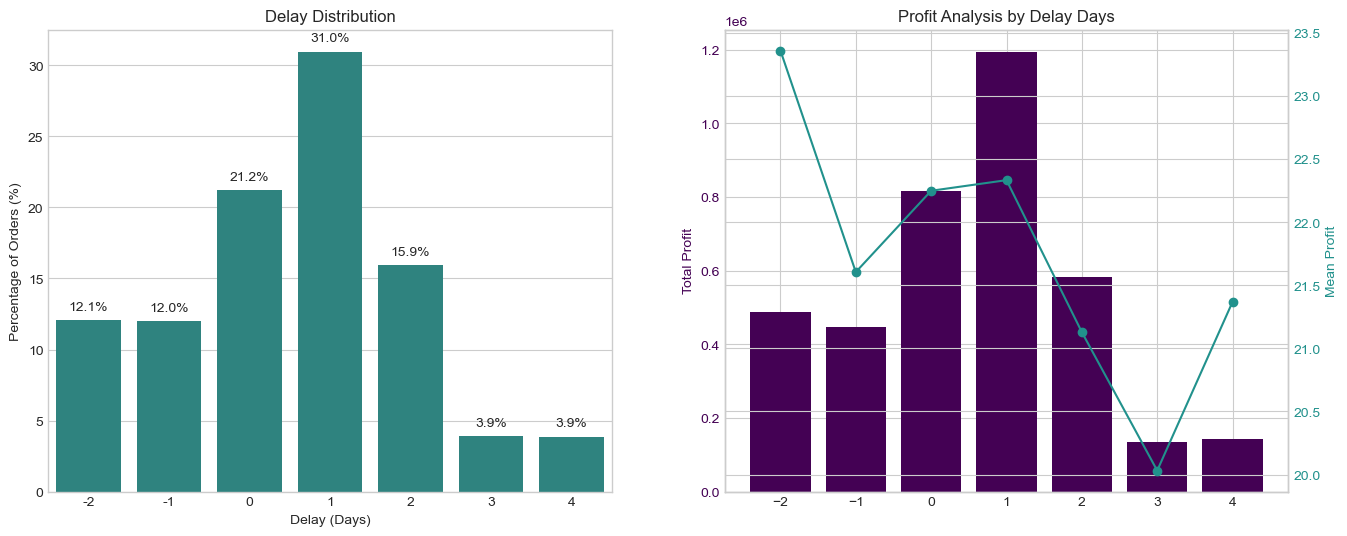

In [30]:
# Analysis of profitibility and Delivery time
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))
# Fist Subplot: Delay Distribution 
sns.barplot(x  = "Delay", y = 'proportion', data = delay_distribution, color= accent_color, ax = ax1)
ax1.set_title("Delay Distribution")
ax1.set_xlabel("Delay (Days)")
ax1.set_ylabel('Percentage of Orders (%)')

# percentage text on bars 
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha = 'center', va= 'bottom')

# second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color = primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color = primary_color, label = 'Total Profit')
ax2.tick_params(axis= 'y', labelcolor = primary_color)


ax3 = ax2.twinx()

ax3.set_title("Profit Analysis by Delay Days")
ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color = accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker = 'o', label ='Mean Profit', color = accent_color)
ax3.tick_params(axis = 'y', labelcolor = accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $' 



# Bottleneck Detection

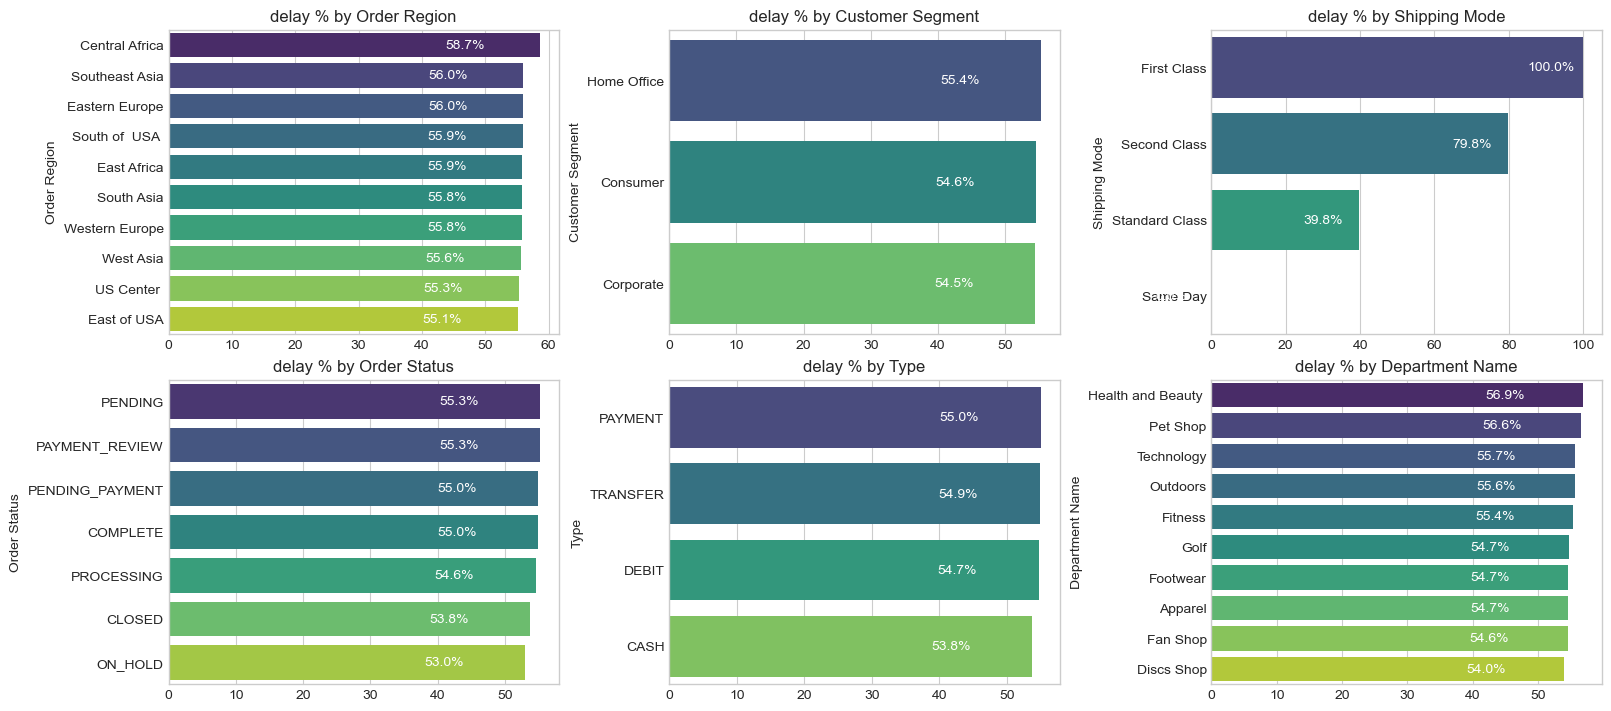

In [31]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders = ('Delay', 'count'),
        late_orders = ('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending = False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize =(16, 7), constrained_layout = True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data = cat_df,
        x = 'delay_pct',
        y = category,
        ax = ax,
        palette = 'viridis'
    )
    ax.set_title(f"delay % by {category}")
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct']-15, i, f"{row['delay_pct']:.1f}%", va = 'center', fontsize = 10, color = 'white')

plt.show()

In [32]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,30817,17060,55.359055
0,Consumer,89420,48855,54.635428
1,Corporate,52528,28608,54.462382


Root cause Analysis

In [33]:
# Find the root cause for delay delivery in region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factor = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders = ('Delay', 'count'),
                late_orders = ('Is_Delayed', 'sum'),
                avg_delay = ('Delay', 'mean')
            ).reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_level'] = str(factor) + ';' + temp[factor].astype(str)

        all_factor.append(temp[['Driver', 'Factor_level', 'delay_pct', 'avg_delay', 'total_orders']])

    #combine all drivers
    final_df = pd.concat(all_factor)


    # Top 10 drivers
    top_factor = final_df.sort_values('delay_pct', ascending = False).head(10)
    plt.figure()

    bars = plt.barh(top_factor['Factor_Level'], top_factor['delay_pct'])

    # Visual style

    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver Factors')
    plt.title(f'Top Drivers of Late Delivery in {region}')
    plt.grid(True, linestyle = ':', alpha = 0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va = 'center', fontsize = 10, color = 'white')
    plt.show()

top_drivers_for_region('Central Africa')


KeyError: 'Factor_Level'

<Figure size 640x480 with 0 Axes>

In [ ]:
df['Order Region'].head(5)

0    Southeast Asia
1        South Asia
2        South Asia
3           Oceania
4           Oceania
Name: Order Region, dtype: object

Time Frame Analysis

In [ ]:
print('Maximum Date of Orders:')
print(df['order date (DateOrders)'].max())
print('Minimum Date of Orders:')
print(df['order date (DateOrders)'].min())

Maximum Date of Orders:
2018-01-31 23:38:00
Minimum Date of Orders:
2015-01-01 00:00:00


In [ ]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()

)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()

)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100



In [ ]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


In [ ]:
# Take a look how much delay by week days
delay_by_day

,order_day,Is_Delayed,delay_pct
0,1,0.549749,54.974909
1,2,0.555942,55.594163
2,3,0.544701,54.470142
3,4,0.569817,56.981740
4,5,0.554683,55.468332
5,6,0.545966,54.596590
6,7,0.550086,55.008636
7,8,0.540061,54.006149
8,9,0.547294,54.729370
9,10,0.541862,54.186214


 Machine Learning Modeling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE 

In [43]:
x = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_month', 'order_hour']]
y = df['Late_delivery_risk']

In [44]:
x.head(4)

,Type,Days for shipment (scheduled),Category Name,Customer Segment,Department Name,Order Region,Shipping Mode,order_month,order_hour
0,DEBIT,4,Sporting Goods,Consumer,Fitness,Southeast Asia,Standard Class,1,22
1,TRANSFER,4,Sporting Goods,Consumer,Fitness,South Asia,Standard Class,1,12
2,CASH,4,Sporting Goods,Consumer,Fitness,South Asia,Standard Class,1,12
3,DEBIT,4,Sporting Goods,Home Office,Fitness,Oceania,Standard Class,1,11


In [46]:
# Feature Engineering

cat_cols = x.select_dtypes(include = ['object', 'category']).columns.tolist()
print('Categorical Columns:', cat_cols)

# Frequency encoding (low-dimentional and robust for high-cardinality)
for col in cat_cols:
    freq = x[col].value_counts(normalize= True)
    x[f'{col}_freq'] = x[col].map(freq)


# Keep numeric columns + new encoded features, drop orginal string categories
x_encoded = x.drop(columns = cat_cols)
print('Shape after freq+target encoding:', x_encoded.shape)


# Use encoded features for modeling
x = x_encoded 


# trin/rest split after encoding 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state= 42, stratify= y
)

Categorical Columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [47]:
# Check the data is balenced or imbalenced
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [51]:
# Balencing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [54]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n------{model_name}----------")
    print("Accuracy:", round(accuracy_score(y_true,  y_pred),2))
    print("Precision:", round(precision_score(y_true, y_pred),2))
    print("Recall:", round(recall_score(y_true, y_pred),2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))



In [58]:
# Fit the Random Forest model on Balenced data
rf_model_balanced = RandomForestClassifier(random_state = 42)
rf_model_balanced.fit(x_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(x_test)

evaluate_model(y_test, y_pred_rf_balanced, 'Random Forest Classifier')


------Random Forest Classifier----------
Accuracy: 0.74
Precision: 0.79
Recall: 0.75

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553

